***Project 1 :***
# ***Exploratory Data Analysis & Insights Report***

Importing required libraries for the project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Uploadinding the Dataset taken from Kaggle
Dataset Name : netflix_titles.csv

In [2]:
from google.colab import files
print('Please upload the netflix_titles.csv file: ')
uploaded = files.upload()

Please upload the netflix_titles.csv file: 


Saving netflix_titles.csv to netflix_titles.csv


**Loading the dataset**

In [3]:
df = pd.read_csv("netflix_titles.csv")

Displaying the dataset

To understand:


*   Columns
*   Values
*   Data style



In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Checking the shape of data by df.shape

To find rows and columns in the dataset

The dataset has 8807 rows and 12 columns

In [5]:
df.shape

(8807, 12)

Understanding the features in the dataset by displaying column names

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Knowing the information of the dataset.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Now checking the missing values of the dataset.

In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Now checking the dupicate or repeated rows in the dataset.

In [9]:
df.duplicated().sum()

np.int64(0)

Statistical summary of the dataset

In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


###**Dataset Summary**

1. Dataset contains infromation about the Netflix moves and TV shows.
2. Netflix dataset has 8807 rows and 12 columns.
3. Columns of the dataset contains **Features** of the dataset such as
   show_id, type, title, director, cast, country, date_added,
       release_year, rating, duration, listed_in, description.
4. From the above features some of the columns like director, cast,
   country, etc. contains missing values.
5. Netflix dataset can be useful to analyze Netflix content categories,
   releasing content patterns and trends.

Rechecking the missing values in the dataset.

In [11]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


Cleaning the missing values from the director column.

I filled missing values using "Unknown" instead of removing rows because many records were missing director information and deleting them would reduce the dataset size.

In [12]:
df['director'] = df['director'].fillna('Unknown')

Cleaning the cast column by replacing missing values with "Not Available" to preserve dataset record.

In [13]:
df['cast'] = df['cast'].fillna('Not Available')

Handling the missing values from column country by replacing them with "Not Specified" to maintain completeness of the dataset.

In [14]:
df['country'] = df['country'].fillna('Not Specified')

Missing rating records were replaced by "Unrated".

In [15]:
df['rating'] = df['rating'].fillna('Unrated')

Rows with missing values in the date_added column were removed because the number of missing records was very small.

In [16]:
df.dropna(subset = ['date_added'], inplace = True)

The rows with missing records in the duration column were removed because the number of missing records was very small.

In [17]:
df.dropna(subset = ['duration'], inplace = True)

Checking the datatype.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8794 non-null   object
 1   type          8794 non-null   object
 2   title         8794 non-null   object
 3   director      8794 non-null   object
 4   cast          8794 non-null   object
 5   country       8794 non-null   object
 6   date_added    8794 non-null   object
 7   release_year  8794 non-null   int64 
 8   rating        8794 non-null   object
 9   duration      8794 non-null   object
 10  listed_in     8794 non-null   object
 11  description   8794 non-null   object
dtypes: int64(1), object(11)
memory usage: 893.1+ KB


converting date_added column.

In [19]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

df.info() is used to verify after converting.

Now we get to see the datatype
datetime64[ns]

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8794 non-null   object        
 1   type          8794 non-null   object        
 2   title         8794 non-null   object        
 3   director      8794 non-null   object        
 4   cast          8794 non-null   object        
 5   country       8794 non-null   object        
 6   date_added    8794 non-null   datetime64[ns]
 7   release_year  8794 non-null   int64         
 8   rating        8794 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8794 non-null   object        
 11  description   8794 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 893.1+ KB


show_id column was removed because it acts as a unique identifier.

It has no contribution for analysis.

In [21]:
df.drop('show_id', axis = 1, inplace = True)

The dataset is now cleaned and ready for further analysis.


In [22]:
df.isnull().sum()

,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


using df.info() and df.columns for checking and cleanig the dataset.

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8794 non-null   object        
 1   title         8794 non-null   object        
 2   director      8794 non-null   object        
 3   cast          8794 non-null   object        
 4   country       8794 non-null   object        
 5   date_added    8794 non-null   datetime64[ns]
 6   release_year  8794 non-null   int64         
 7   rating        8794 non-null   object        
 8   duration      8794 non-null   object        
 9   listed_in     8794 non-null   object        
 10  description   8794 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 824.4+ KB


In [24]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

###**Data Cleaning Summary**


*   In the columns such as director, cast, country and rating there were missing values and they were handled by replacing them with placeholders like "Unknown", "Not Available", "Not Specified", "Unrated".

*   Rows containing missing values in date_added and duration were removed because the number of missing records was very small.

*   The datatype of the date_added column was converted from object to datetime64[ns] to make date-based analysis possible.
*   The show_id column was removed from the dataset because it acts only as an identifier and is not useful for analytical purposes.

*   After cleaning, the dataset became more complete and consistent, containing 8794 rows and 11 columns with no remaining missing values.






**Exploratory Data Analysis (EDA)**

###Q.1) How many Movies and TV Shows are available on Netflix?

In [25]:
df['type'].value_counts()

,count
type,
Movie,6128
TV Show,2666


Explanation:

###EDA Q.1) Movies vs TV Shows counts

Using `value.counts()` to count the number of movies and TV shows in the dataset.

In the output we can see the distribution of content types present on Netflix.


###Q.2) Which countries contribute the most Netflix content?

In [26]:
df['country'].value_counts().head(10)

,count
country,
United States,2809
India,972
Not Specified,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


Explanation:

### EDA Q.2) Top Netflix Content producing Countries.


Using `value_counts()` to identify the countries producing the highest amount of Netflix content.

The result shows the top countries contributing content to Netflix.

### Q.3) Which ratings appear most frequently?


In [27]:
df['rating'].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


Explanation:

### EDA Q.3) Content Rating Analysis

Using `value_counts()` to analyze the frequency of content ratings.


The output shows which audience ratings are most common in the dataset.

### Q.4) How has Netflix content changed across years?


In [28]:
df['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1031
2018,1146
2019,1030


Explanation:

### EDA Q.4) Release Year Analysis

Using `value_counts()` and `sort_index()` to examine content distribution across release years.

This analysis helps understand Netflix content growth trends over time.

### Q.5) Which directors have the most content on Netflix?

In [29]:
df['director'].value_counts().head(10)

,count
director,
Unknown,2624
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Suhas Kadav,16
Jay Karas,14
Cathy Garcia-Molina,13
Jay Chapman,12
Youssef Chahine,12


Explanation:

### EDA Q.5) Top Directors

Using `value_counts()` to identify directors with the highest number of titles in the dataset.

The output highlights directors contributing the most Netflix content.

## Exploratory Data Analysis (EDA) Summary

  

*   The analysis showed that **Movies dominate Netflix content**, with a much larger number of movies compared to TV Shows in the dataset.

*   The **United States contributes the highest amount of Netflix content**, followed by countries such as India and the United Kingdom.

*   Content ratings analysis revealed that **TV-MA and TV-14 are the most common ratings**, indicating that a large portion of Netflix content is targeted toward mature and teen audiences.

*   Release year analysis helped understand **Netflix content distribution across different years**, showing significant growth in content production in recent years.

*   Director analysis identified the **top directors contributing content to Netflix**, while also showing that many records originally had missing director information which had been replaced during data cleaning.

### **VISUALIZATIONS**

### **Chart 1 : Bar chart**

Movies VS TV Shows

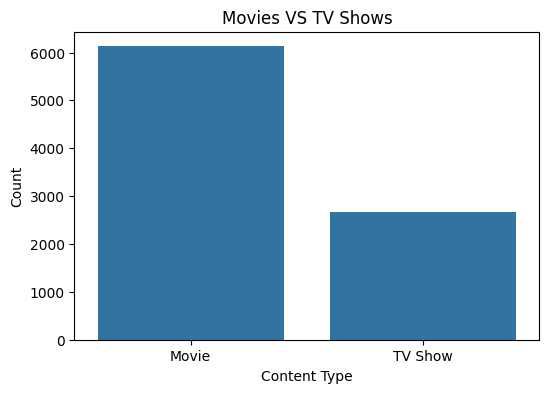

In [30]:
plt.figure(figsize=(6, 4))

sns.countplot(x = 'type', data = df)

plt.title('Movies VS TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

**Explanation**
### Visualization 1 : Bar Chart
A bar chart was created to compare the number of Movies and TV Shows available on Netflix.

In the result, the visualization clearly shows the Movies are more numerous than TV Shows.

### **Chart 2 : Line Chart**
Content growth by release year

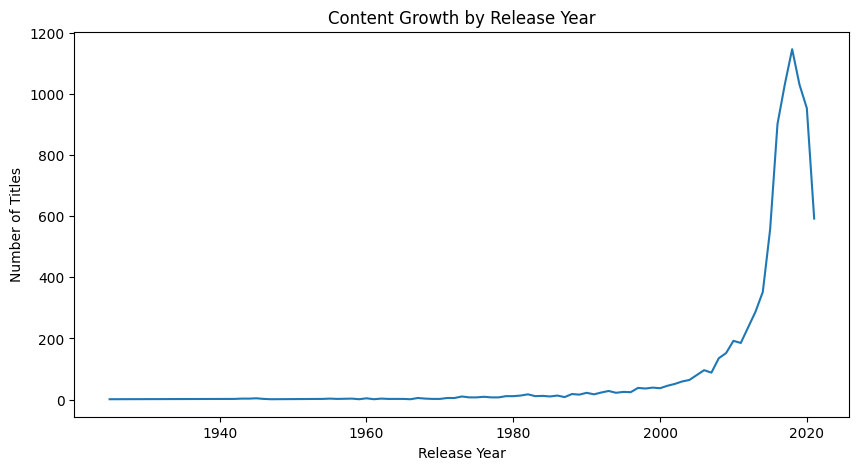

In [31]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(year_counts.index, year_counts.values)

plt.title('Content Growth by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()

**Explanation**
### Visualization 2 : Line Chart

A line chart was used to examine how netflix content changed across release years.

In the output, the chart helps to identify growth trends in Netflix content over time.

###  **Chart 3 : Histogram**

Release Year Distribution

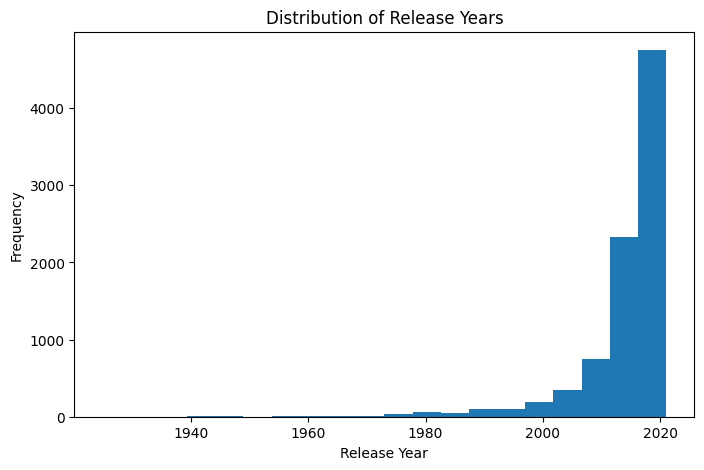

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(df['release_year'], bins = 20)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')

plt.show()

**Explanation**
### Visualization 3 : Histogram

A histogram was created to observe the distribution of the release years in the dataset.

In the output, the chart sows how titles are distributed across different release periods.

### **Chart 4 : Pie Chart**

Content Ratings Distribution

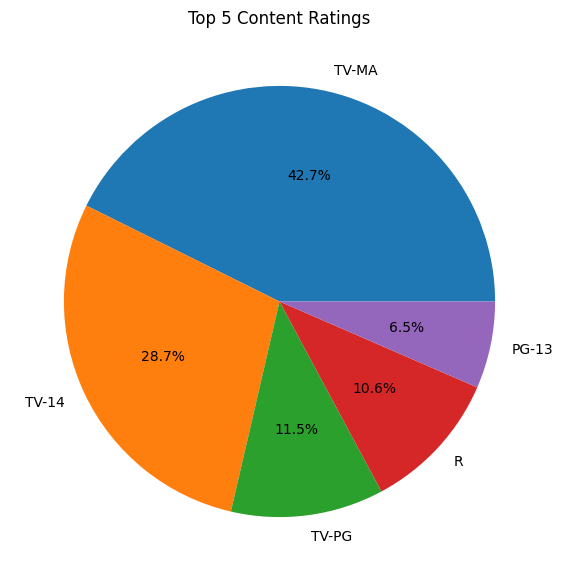

In [33]:
rating_counts = df['rating'].value_counts().head(5)

plt.figure(figsize=(7, 7))

plt.pie(
    rating_counts.values,
    labels=rating_counts.index,
    autopct='%1.1f%%'
)

plt.title('Top 5 Content Ratings')

plt.show()

**Explanation**

### Visualization 4 : Pie Chart

A pie chart was crreated to display the proportion of top content ratings.

In the output, the chart highlights the dominant audience rating categories on Netflix.

### **Chart 5 : Heatmap**

Missing vaues checking

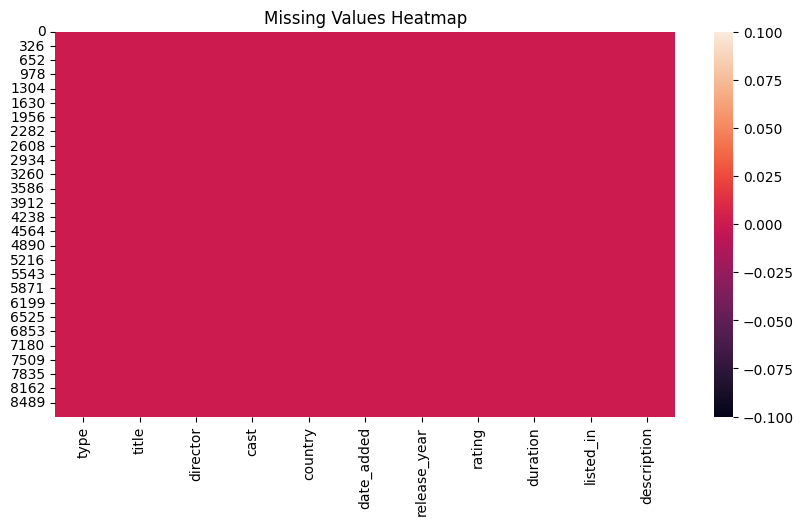

In [34]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull())
plt.title('Missing Values Heatmap')

plt.show()

**Explanation**

### Visualization 5 : Heatmap

A heatmap was created to visually inspect missing values in the dataset.

In the result, the heatmap confirms that the dataset contains no remaining missing values after cleaning.

### **Chart 6 : Scatter Plot**

Release Year VS Duration

In [35]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3887/1891223089.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(int)


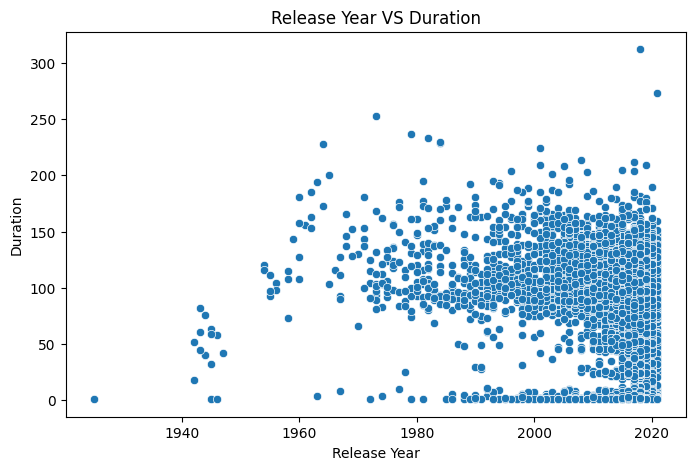

In [36]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x = 'release_year',
    y = 'duration_num',
    data = df
)

plt.title('Release Year VS Duration')
plt.xlabel('Release Year')
plt.ylabel('Duration')

plt.show()

**Explanation**

### Visualization 6 : Scatter Plot

A scatter plot was used to examine the relationship between release year and duration.

In the output, the chart shows how content varies across different release years.

### **Visualization Summary**



*   **Bar Chart - Movies vs TV Shows**
     
     The bar chart was used to compare Movies and TV Shows available on Netflix, showing that Movies are present in much higher number.  

*   **Line Chart - Content Growth by Release Year**
     
     The line chart helped visualize how Netflix content changed across release years and showed overall content growth over time.

*   **Histogram — Release Year Distribution**

      The histogram displayed the frequency distribution of release years, helping understand how titles are distributed across different periods.

*   **Pie Chart — Content Ratings Distribution**

    The pie chart illustrated the proportion of top content ratings, highlighting the most dominant audience rating categories on Netflix.

*   **Heatmap — Missing Values Analysis**
    
    The heatmap visually verified the dataset’s missing values status and confirmed that the dataset was successfully cleaned.

*   **Scatter Plot — Release Year vs Duration**
    
    The scatter plot was used to examine the relationship between release year and content duration, showing how duration varies across different years.




### **Insights Report & Most Surprising Finding**

**Insight 1 :**

Movies dominate Netflix content.

Based on:
EDA Q.1 & Bar Chart

Reference:

Movies → 6128

TV Shows → 2666

**Notebook Insight:**

Netflix contains significantly more Movies than TV Shows. This suggest that the platform focuses heavily on movie content compared to episodic television content.

**Insight 2:**

United States dominates content production.

Based on:
EDA Q.2

Reference:

United States → 2809 titles


**Notebook Insight:**

The United States contributes the highest amount of Netflix content, indicating its strong influence on the platform’s content library. Countries like India and the United Kingdom also contribute substantial amounts of content.

**Insight 3:**

Mature audience content is dominant.

Based on:

EDA Q3 + Pie Chart

Reference:

TV-MA → 3205

TV-14 → 2157

**Notebook Insight:**

TV-MA and TV-14 are the most common content ratings on Netflix. This suggests that a large portion of Netflix content is targeted toward mature and teenage audiences.

**Insight 4:**

Netflix content increased strongly in recent years.

Based on:

EDA Q4 + Line Chart + Histogram

Reference:

Recent years show significantly higher content counts compared to earlier years.

**Notebook Insight:**

Release year analysis shows strong growth in Netflix content production during recent years. This indicates an expansion in content availability and increased platform activity over time.

**Insight 5:**

Director information plays an important role.

Based on:

EDA Q5 + Heatmap + Cleaning Process

Reference:

Many missing directors.

**Notebook Insight:**

The dataset originally contained a large number of missing director records. After cleaning, the analysis highlighted major contributing directors, showing the importance of accurate metadata for content analysis.

###   **Most Surprising Finding**

The most surprising finding from this analysis was the dominance of movie content on Netflix compared to TV Shows. Another interesting observation was the large amount of content coming from the United States. It was also surprising to see how rapidly Netflix content increased during recent years.

### **Project Conclusion**

In this project, the Netflix Movies and TV Shows dataset was analyzed using Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn. The dataset was inspected, cleaned, and explored to understand its structure and identify meaningful patterns.

Through Exploratory Data Analysis (EDA), key information such as content type distribution, top content-producing countries, audience ratings, release year trends, and director contributions was examined. Various visualizations including bar charts, line charts, histograms, pie charts, heatmaps, and scatter plots were created to present the findings clearly.

The analysis revealed that Movies dominate Netflix content, the United States contributes the largest share of content, mature audience ratings are the most common, and Netflix content production has increased significantly in recent years. These insights provide a better understanding of Netflix's content library and distribution trends.
